In [30]:
import polars as pl
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc, average_precision_score
from sklearn.model_selection import PredefinedSplit, GridSearchCV, RandomizedSearchCV
import plotly.express as px
import joblib
# path = "/home/jovyan/work/"

In [31]:
features_df = (
    pl.scan_parquet(f"{path}data/gold/Polars/feature_complete_fraud_data.parquet")
    .select(pl.all().exclude("client_id", "card_id", "date", 
                             # "id", 
                             "merchant_latitude", "merchant_longitude"
                            ))
)

features_df.show(5)

id,target,agemonth_at_event,days_acct_open,days_expires,retirement_years,No_Errors,Bad_Card_Number,Bad_CVV,Bad_Expiration,Bad_PIN,Bad_Zipcode,Insufficient_Balance,Technical_Glitch,Visa,Discover,Amex,Mastercard,Debit_Prepaid,Credit,Debit,Online_Transaction,Chip_Transaction,Swipe_Transaction,Male,Log2_risk_factor,amount,credit_limit,yearly_income,total_debt,sum_amount_24h,mean_log_amount_7d,stddev_log_amount_7d,sum_amount_7d,is_refund,acceleration_ratio_24h_vs_7d,ratio_24_credit_limit,…,is_tdiffm_in_IC95,is_tdiffm_in_IC99,hour_of_day,theta,sin_theta,cos_theta,N_7d,day_of_week,weekend,mu_vM_7d,sigma_vM_7d,ic_lower_vm_90_7d,ic_upper_vm_90_7d,ic_lower_vm_95_7d,ic_upper_vm_95_7d,ic_lower_vm_99_7d,ic_upper_vm_99_7d,is_time_in_IC_90,is_time_in_IC_95,is_time_in_IC_99,log_time_diff_m,mean_time_diff_m,stddev_time_diff_m,ic_lower_tdiffm_90,ic_upper_tdiffm_90,ic_lower_tdiffm_95,ic_upper_tdiffm_95,ic_lower_tdiffm_99,ic_upper_tdiffm_99,is_tdiffm_in_IC90_right,is_tdiffm_in_IC95_right,is_tdiffm_in_IC99_right,acceleration_ratio_24h_vs_7d_is_inf,ratio_24_credit_limit_is_inf,ratio_24_total_debt_is_inf,speed_km_s_is_inf,mean_speed_km_s_is_inf
str,bool,i64,i64,i64,i64,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,f64,f64,…,bool,bool,f64,f64,f64,f64,u32,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool,bool,bool,bool,bool,bool,bool
"""13047138""",false,328,899,2812,500,true,false,false,false,false,false,false,false,false,false,false,true,false,false,true,false,false,true,true,0.5,42.52,31490.0,59613.0,36199.0,52.38,3.660233,0.861347,562.84,false,0.093064,0.001663,…,true,true,13.383333,-2.779437,-0.354291,-0.935135,14,5,true,-1.663538,1.198727,-2.230898,-1.096179,-2.355663,-0.971414,-2.628591,-0.698486,false,false,false,7.248504,5.526262,1.964124,4.596639,6.455886,4.392211,6.660314,3.945016,7.107509,false,false,false,false,false,false,false,false
"""13048785""",false,328,899,2812,500,true,false,false,false,false,false,false,false,false,false,false,true,false,false,true,false,false,true,true,-0.18,37.51,31490.0,59613.0,36199.0,52.79,3.667118,0.831563,605.25,false,0.08722,0.001676,…,true,true,20.583333,-0.894481,-0.779884,0.625923,15,5,true,-1.777568,1.205201,-2.325655,-1.22948,-2.444986,-1.110149,-2.703907,-0.851229,false,false,true,2.833213,5.643853,1.944779,4.759429,6.528277,4.566871,6.720836,4.149062,7.138644,false,false,false,false,false,false,false,false
"""13051758""",false,328,900,2811,500,true,false,false,false,false,false,false,false,false,false,false,true,false,false,true,false,false,true,true,2.45,44.17,31490.0,59613.0,36199.0,90.3,3.641438,0.859551,551.63,false,0.163697,0.002868,…,true,true,13.3,-2.801253,-0.333807,-0.942641,14,6,true,-1.651931,1.195052,-2.217551,-1.08631,-2.341933,-0.961928,-2.614025,-0.689837,false,false,false,6.911747,5.48505,2.067322,4.506582,6.463517,4.291413,6.678686,3.820722,7.149377,false,false,true,false,false,false,false,false
"""13063377""",false,328,903,2808,500,true,false,false,false,false,false,false,false,false,false,false,true,false,false,true,false,false,true,true,-3.73,14.5,31490.0,59613.0,36199.0,47.47,3.814873,0.60868,434.15,false,0.10934,0.001507,…,true,true,6.7,1.754056,0.983255,-0.182236,11,2,false,-2.445773,1.100984,-3.047436,-1.84411,3.097761,-1.706122,2.785344,-1.393704,false,false,false,6.957497,5.535058,2.399648,4.223704,6.846412,3.922953,7.147164,3.242022,7.828094,false,true,true,false,false,false,false,false
"""13065451""",false,328,903,2808,500,true,false,false,false,false,false,false,false,false,false,false,true,false,false,true,true,false,false,true,-0.81,16.73,31490.0,59613.0,36199.0,14.5,3.70915,0.687576,400.06,false,0.036245,0.00046,…,true,true,14.25,-2.552544,-0.55557,-0.83147,11,2,false,-2.56345,1.320764,2.997968,-1.841682,2.832434,-1.676148,2.457651,-1.301365,true,true,true,6.118097,5.548354,2.407817,4.232536,6.864172,3.93076,7.165948,3.247512,7.

In [3]:
df = features_df.collect()

In [4]:
proporciones = df.group_by("target").agg([
    pl.len().alias("cantidad"),
    (pl.len() / len(df) * 100).alias("porcentaje")
])

print(proporciones)

shape: (2, 3)
┌────────┬──────────┬────────────┐
│ target ┆ cantidad ┆ porcentaje │
│ ---    ┆ ---      ┆ ---        │
│ bool   ┆ u32      ┆ f64        │
╞════════╪══════════╪════════════╡
│ false  ┆ 3112100  ┆ 99.706082  │
│ true   ┆ 9174     ┆ 0.293918   │
└────────┴──────────┴────────────┘


In [16]:
False_df = df.filter(~pl.col("target"))
False_train_df = False_df.sample(fraction=0.70, seed=777)
False_valtest_df = False_df.join(False_train_df, on="id", how="anti")
False_val_df = False_valtest_df.sample(fraction=0.50, seed=777)
False_test_df = False_valtest_df.join(False_val_df, on="id", how="anti")

True_df = df.filter(pl.col("target"))
True_train_df = True_df.sample(fraction=0.70, seed=777)
True_valtest_df = True_df.join(True_train_df, on="id", how="anti")
True_val_df = True_valtest_df.sample(fraction=0.50, seed=777)
True_test_df = True_valtest_df.join(True_val_df, on="id", how="anti")

## Tomaremos solo 100_000 transaciones legitimas para el entrenamiento ya que hay un alto desbalance entre
## las transacciones legítimas y las fraudulentas
balanced_False_train_df = False_train_df.sample(n=100_000, seed=777)

train_df = pl.concat([balanced_False_train_df, True_train_df]).sample(fraction=1.0, shuffle=True, seed=777)
val_df = pl.concat([False_val_df, True_val_df]).sample(fraction=1.0, shuffle=True, seed=777)
test_df = pl.concat([False_test_df, True_test_df]).sample(fraction=1.0, shuffle=True, seed=777)


## Definimos los datos que usaremos para el entrenamiento, la validación, el testeo del modelo
## y la búsqueda de hiperparámetros
X_train = train_df.drop("target", "id")
y_train = train_df.select("target").to_numpy().ravel()

X_val = val_df.drop("target", "id")
y_val = val_df.select("target").to_numpy().ravel()

X_test = test_df.drop("target", "id")
y_test = test_df.select("target").to_numpy().ravel()

X_search = pl.concat([X_train, X_val])
y_search = np.concatenate((y_train, y_val))

split_indices = np.zeros(len(X_search))
split_indices[:len(X_train)] = -1  
split_indices[len(X_train):] = 0   
pds = PredefinedSplit(test_fold=split_indices)

In [20]:
rf_0 = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12, 
    class_weight="balanced", 
    random_state=777, 
    n_jobs=-1,
    verbose=0
)

rf_0.fit(X_train, y_train)

val_probs = rf_0.predict_proba(X_val)[:, 1]
calibrated_threshold = 0.7  
calibrated_val_preds = val_probs > calibrated_threshold

print("-------- VALIDATION REPORT --------")
print(classification_report(y_val, calibrated_val_preds))

-------- VALIDATION REPORT --------
              precision    recall  f1-score   support

       False       1.00      0.99      1.00    466815
        True       0.22      0.80      0.34      1376

    accuracy                           0.99    468191
   macro avg       0.61      0.89      0.67    468191
weighted avg       1.00      0.99      0.99    468191



In [21]:
test_probs_0 = rf_0.predict_proba(X_test)[:, 1]
final_test_preds = test_probs_0  > calibrated_threshold  

print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds))

-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

       False       1.00      0.99      1.00    466815
        True       0.22      0.78      0.34      1377

    accuracy                           0.99    468192
   macro avg       0.61      0.89      0.67    468192
weighted avg       1.00      0.99      0.99    468192



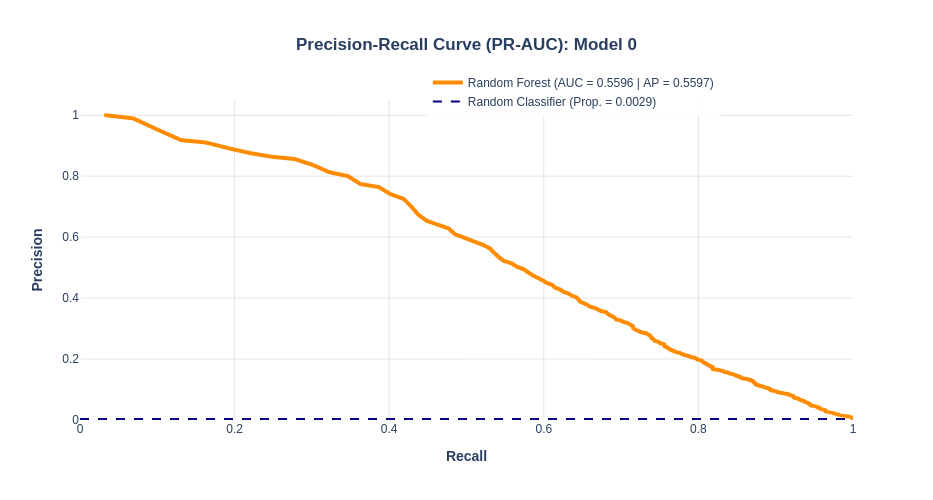

In [55]:
precision, recall, thresholds = precision_recall_curve(y_test, test_probs_0)
pr_auc_score = auc(recall, precision)
ap_score = average_precision_score(y_test, test_probs_0)

PRAUC_df = pl.DataFrame({"Recall": recall, "Precision": precision})

light_PRAUC_df = PRAUC_df.gather_every(50)
baseline = float(y_test.sum() / len(y_test))

fig = px.line(
    light_PRAUC_df, 
    x='Recall', 
    y='Precision',
    title='<b>Precision-Recall Curve (PR-AUC): Model 0</b>',
    labels={'Recall': '<b>Recall<b>', 'Precision': '<b>Precision<b>'}
)

fig.update_traces(
    line=dict(color='darkorange', width=4),
    name=f'Random Forest (AUC = {pr_auc_score:.4f} | AP = {ap_score:.4f})',
    showlegend=True,
    hovertemplate='<b>Recall:</b> %{x:.4f}<br><b>Precision:</b> %{y:.4f}<extra></extra>'
)

fig.add_shape(
    type="line", x0=0, y0=baseline, x1=1, y1=baseline,
    line=dict(color="navy", width=2, dash="dash"),
)

fig.add_trace(px.scatter(x=[None], y=[None], labels={'x':'', 'y':''}).data[0])

fig.data[-1].update(
    name=f'Random Classifier (Prop. = {baseline:.4f})', 
    showlegend=True, mode='lines',
    line=dict(color="navy", width=2, dash="dash")
)

fig.update_layout(
    width=700, height=500, title_x=0.5, autosize=False,
    xaxis=dict(range=[0.0, 1.0], gridcolor='rgba(0,0,0,0.1)'),
    yaxis=dict(range=[0.0, 1.05], gridcolor='rgba(0,0,0,0.1)'),
    plot_bgcolor='white',
    legend=dict(x=0.45, y=1.1, bgcolor='rgba(255, 255, 255, 0.8)')
)

fig.show()

In [35]:
# joblib.dump(rf_0, f"{path}mldl/ML_RandomForest_0.pkl")

In [9]:
param_dist = {
    'n_estimators': [100, 300, 500],         
    'max_depth': [12, 16, 20, None],     
    'min_samples_split': [2, 5, 10],        
    'min_samples_leaf': [1, 2, 5],     
    'max_features': ['sqrt', 'log2', 0.3]
}

grid_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced", 
        random_state=777, 
        n_jobs=1  
    ),
    param_distributions=param_dist,
    n_iter=10,    
    cv=pds,
    scoring="average_precision", 
    verbose=3,  
    n_jobs=2          
)

grid_search.fit(X_search, y_search)
best_rf_1 = grid_search.best_estimator_

print("\n--- BEST HYPERPARAMETERS FOUND ---")
print(grid_search.best_params_)

test_probs_1 = best_rf_1.predict_proba(X_test)[:, 1]

calibrated_threshold = 0.45
final_test_preds = test_probs > calibrated_threshold

print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds))

Fitting 1 folds for each of 10 candidates, totalling 10 fits


/home/diego/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/diego/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/diego/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/diego/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the

[CV 1/1] END max_depth=20, max_features=0.3, min_samples_leaf=5, min_samples_split=2, n_estimators=500;, score=0.612 total time=17.4min
[CV 1/1] END max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=2, n_estimators=500;, score=0.636 total time= 3.9min
[CV 1/1] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100;, score=0.613 total time= 1.1min
[CV 1/1] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=500;, score=0.640 total time= 4.0min


/home/diego/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/1] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=300;, score=0.632 total time= 2.3min
[CV 1/1] END max_depth=16, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=100;, score=0.602 total time= 1.0min
[CV 1/1] END max_depth=12, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=500;, score=0.615 total time= 3.5min
[CV 1/1] END max_depth=12, max_features=log2, min_samples_leaf=5, min_samples_split=2, n_estimators=300;, score=0.617 total time= 2.1min
[CV 1/1] END max_depth=None, max_features=0.3, min_samples_leaf=2, min_samples_split=10, n_estimators=500;, score=0.604 total time=17.2min
[CV 1/1] END max_depth=None, max_features=0.3, min_samples_leaf=2, min_samples_split=10, n_estimators=300;, score=0.603 total time= 9.2min

--- BEST HYPERPARAMETERS FOUND ---
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}


/home/diego/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

       False       1.00      1.00      1.00    466815
        True       0.60      0.56      0.58      1377

    accuracy                           1.00    468192
   macro avg       0.80      0.78      0.79    468192
weighted avg       1.00      1.00      1.00    468192



In [17]:
calibrated_threshold = 0.2
final_test_preds = test_probs > calibrated_threshold

print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds))

-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

       False       1.00      0.99      1.00    466815
        True       0.26      0.80      0.40      1377

    accuracy                           0.99    468192
   macro avg       0.63      0.90      0.70    468192
weighted avg       1.00      0.99      0.99    468192



In [38]:
param_dist = {
    'n_estimators': [500],         
    'max_depth': [None],     
    'min_samples_split': [5],        
    'min_samples_leaf': [2],     
    'max_features': ['log2'],
    'bootstrap': [True, False],
    'criterion': ["gini", "entropy"],
}

grid_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=777, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=4,    
    cv=pds,
    scoring="average_precision", 
    verbose=3,  
    n_jobs=-1          
)

grid_search.fit(X_search, y_search)
best_rf_1 = grid_search.best_estimator_

print("\n--- BEST HYPERPARAMETERS FOUND ---")
print(grid_search.best_params_)

test_probs_1 = best_rf_1.predict_proba(X_test)[:, 1]

calibrated_threshold = 0.45
final_test_preds = test_probs_1 > calibrated_threshold

print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds))

Fitting 1 folds for each of 4 candidates, totalling 4 fits
[CV 1/1] END bootstrap=True, criterion=gini, max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=500;, score=0.640 total time= 2.3min
[CV 1/1] END bootstrap=True, criterion=entropy, max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=500;, score=0.652 total time= 2.5min
[CV 1/1] END bootstrap=False, criterion=gini, max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=500;, score=0.649 total time= 3.0min
[CV 1/1] END bootstrap=False, criterion=entropy, max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=500;, score=0.660 total time= 3.0min

--- BEST HYPERPARAMETERS FOUND ---
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'criterion': 'entropy', 'bootstrap': False}
-------- FINAL TEST REPORT --------
              precisi

In [19]:
calibrated_threshold = 0.2
final_test_preds = test_probs_1 > calibrated_threshold

print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds))

-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

       False       1.00      0.99      1.00    466815
        True       0.28      0.81      0.41      1377

    accuracy                           0.99    468192
   macro avg       0.64      0.90      0.71    468192
weighted avg       1.00      0.99      0.99    468192



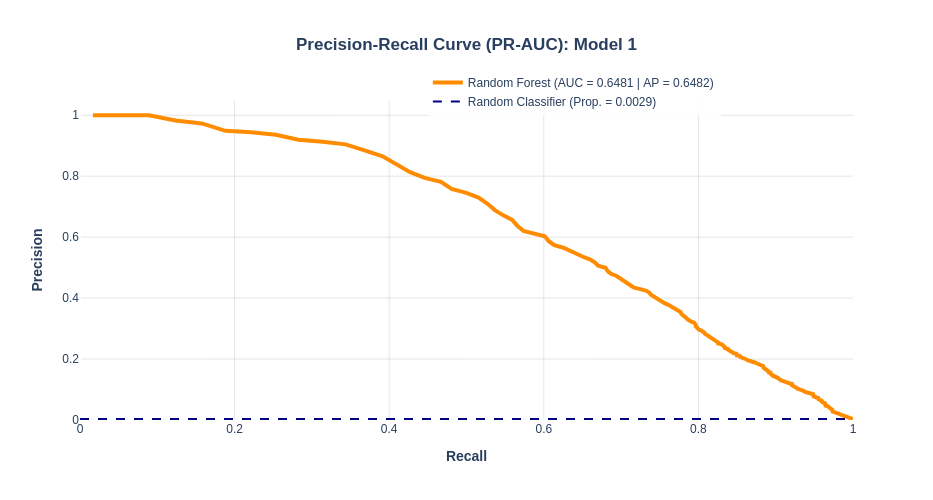

In [56]:
precision, recall, thresholds = precision_recall_curve(y_test, test_probs_1)
pr_auc_score = auc(recall, precision)
ap_score = average_precision_score(y_test, test_probs_1)

PRAUC_df = pl.DataFrame({"Recall": recall, "Precision": precision})

light_PRAUC_df = PRAUC_df.gather_every(50)
baseline = float(y_test.sum() / len(y_test))

fig = px.line(
    light_PRAUC_df, 
    x='Recall', 
    y='Precision',
    title='<b>Precision-Recall Curve (PR-AUC): Model 1</b>',
    labels={'Recall': '<b>Recall<b>', 'Precision': '<b>Precision<b>'}
)

fig.update_traces(
    line=dict(color='darkorange', width=4),
    name=f'Random Forest (AUC = {pr_auc_score:.4f} | AP = {ap_score:.4f})',
    showlegend=True,
    hovertemplate='<b>Recall:</b> %{x:.4f}<br><b>Precision:</b> %{y:.4f}<extra></extra>'
)

fig.add_shape(
    type="line", x0=0, y0=baseline, x1=1, y1=baseline,
    line=dict(color="navy", width=2, dash="dash"),
)

fig.add_trace(px.scatter(x=[None], y=[None], labels={'x':'', 'y':''}).data[0])

fig.data[-1].update(
    name=f'Random Classifier (Prop. = {baseline:.4f})', 
    showlegend=True, mode='lines',
    line=dict(color="navy", width=2, dash="dash")
)

fig.update_layout(
    width=700, height=500, title_x=0.5, autosize=False,
    xaxis=dict(range=[0.0, 1.0], gridcolor='rgba(0,0,0,0.1)'),
    yaxis=dict(range=[0.0, 1.05], gridcolor='rgba(0,0,0,0.1)'),
    plot_bgcolor='white',
    legend=dict(x=0.45, y=1.1, bgcolor='rgba(255, 255, 255, 0.8)')
)

fig.show()

In [37]:
# joblib.dump(best_rf_1, f"{path}mldl/ML_RandomForest_1.pkl")

In [20]:
param_dist = {
    'n_estimators': [100, 300, 500],         
    'max_depth': [12, 16, 20, None],     
    'min_samples_split': [2, 5, 10],        
    'min_samples_leaf': [1, 2, 5],     
    'max_features': ['sqrt', 'log2', 0.3]
}

grid_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced", 
        random_state=777, 
        n_jobs=1  
    ),
    param_distributions=param_dist,
    n_iter=10,    
    cv=pds,
    scoring="f1", 
    verbose=3,  
    n_jobs=2          
)

grid_search.fit(X_search, y_search)
best_rf_2 = grid_search.best_estimator_

print("\n--- BEST HYPERPARAMETERS FOUND ---")
print(grid_search.best_params_)

test_probs_2 = best_rf_2.predict_proba(X_test)[:, 1]

calibrated_threshold = 0.45
final_test_preds = test_probs_2 > calibrated_threshold

print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds))

Fitting 1 folds for each of 10 candidates, totalling 10 fits


/home/diego/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/diego/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/diego/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/diego/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the

[CV 1/1] END max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=5, n_estimators=300;, score=0.326 total time= 2.1min
[CV 1/1] END max_depth=20, max_features=0.3, min_samples_leaf=1, min_samples_split=5, n_estimators=300;, score=0.300 total time= 9.5min
[CV 1/1] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=500;, score=0.450 total time= 4.0min
[CV 1/1] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300;, score=0.369 total time= 3.3min
[CV 1/1] END max_depth=12, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=300;, score=0.225 total time= 2.1min
[CV 1/1] END max_depth=12, max_features=0.3, min_samples_leaf=2, min_samples_split=5, n_estimators=300;, score=0.218 total time= 8.0min
[CV 1/1] END max_depth=12, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.227 total time=  38.7s
[CV 1/1] END max_depth=16, max_features=

/home/diego/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

       False       1.00      1.00      1.00    466815
        True       0.57      0.56      0.57      1377

    accuracy                           1.00    468192
   macro avg       0.79      0.78      0.78    468192
weighted avg       1.00      1.00      1.00    468192



In [27]:
calibrated_threshold = 0.21
final_test_preds = test_probs > calibrated_threshold

print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds))

-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

       False       1.00      0.99      1.00    466815
        True       0.26      0.80      0.39      1377

    accuracy                           0.99    468192
   macro avg       0.63      0.89      0.69    468192
weighted avg       1.00      0.99      0.99    468192



In [39]:
param_dist = {
    'n_estimators': [500],         
    'max_depth': [None],     
    'min_samples_split': [10],        
    'min_samples_leaf': [1],     
    'max_features': ['log2'],
    'bootstrap': [True, False],
    'criterion': ["gini", "entropy"],
}

grid_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=777, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=4,    
    cv=pds,
    scoring="f1", 
    verbose=3,  
    n_jobs=-1          
)

grid_search.fit(X_search, y_search)
best_rf_2 = grid_search.best_estimator_

print("\n--- BEST HYPERPARAMETERS FOUND ---")
print(grid_search.best_params_)

test_probs_2 = best_rf_2.predict_proba(X_test)[:, 1]

calibrated_threshold = 0.45
final_test_preds = test_probs_2 > calibrated_threshold

print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds))

Fitting 1 folds for each of 4 candidates, totalling 4 fits

--- BEST HYPERPARAMETERS FOUND ---
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'criterion': 'gini', 'bootstrap': True}
-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

       False       1.00      1.00      1.00    466815
        True       0.57      0.56      0.57      1377

    accuracy                           1.00    468192
   macro avg       0.79      0.78      0.78    468192
weighted avg       1.00      1.00      1.00    468192



In [30]:
calibrated_threshold = 0.21
final_test_preds = test_probs_2 > calibrated_threshold

print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds))

-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

       False       1.00      0.99      1.00    466815
        True       0.26      0.80      0.39      1377

    accuracy                           0.99    468192
   macro avg       0.63      0.89      0.69    468192
weighted avg       1.00      0.99      0.99    468192

[CV 1/1] END bootstrap=False, criterion=gini, max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=500;, score=0.443 total time= 3.1min
[CV 1/1] END bootstrap=False, criterion=entropy, max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=500;, score=0.442 total time= 3.2min


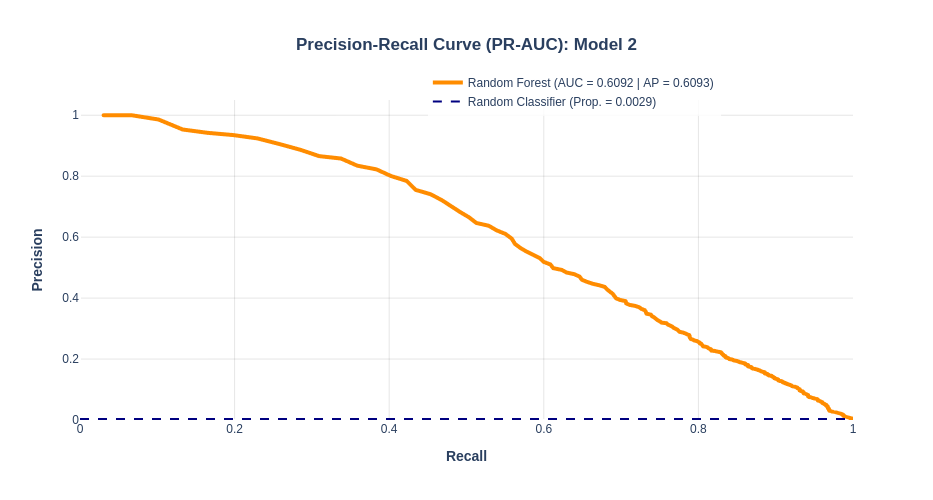

In [57]:
precision, recall, thresholds = precision_recall_curve(y_test, test_probs_2)
pr_auc_score = auc(recall, precision)
ap_score = average_precision_score(y_test, test_probs_2)

PRAUC_df = pl.DataFrame({"Recall": recall, "Precision": precision})

light_PRAUC_df = PRAUC_df.gather_every(50)
baseline = float(y_test.sum() / len(y_test))

fig = px.line(
    light_PRAUC_df, 
    x='Recall', 
    y='Precision',
    title='<b>Precision-Recall Curve (PR-AUC): Model 2</b>',
    labels={'Recall': '<b>Recall<b>', 'Precision': '<b>Precision<b>'}
)

fig.update_traces(
    line=dict(color='darkorange', width=4),
    name=f'Random Forest (AUC = {pr_auc_score:.4f} | AP = {ap_score:.4f})',
    showlegend=True,
    hovertemplate='<b>Recall:</b> %{x:.4f}<br><b>Precision:</b> %{y:.4f}<extra></extra>'
)

fig.add_shape(
    type="line", x0=0, y0=baseline, x1=1, y1=baseline,
    line=dict(color="navy", width=2, dash="dash"),
)

fig.add_trace(px.scatter(x=[None], y=[None], labels={'x':'', 'y':''}).data[0])

fig.data[-1].update(
    name=f'Random Classifier (Prop. = {baseline:.4f})', 
    showlegend=True, mode='lines',
    line=dict(color="navy", width=2, dash="dash")
)

fig.update_layout(
    width=700, height=500, title_x=0.5, autosize=False,
    xaxis=dict(range=[0.0, 1.0], gridcolor='rgba(0,0,0,0.1)'),
    yaxis=dict(range=[0.0, 1.05], gridcolor='rgba(0,0,0,0.1)'),
    plot_bgcolor='white',
    legend=dict(x=0.45, y=1.1, bgcolor='rgba(255, 255, 255, 0.8)')
)

fig.show()

In [47]:
# joblib.dump(best_rf_2, f"{path}mldl/ML_RandomForest_2.pkl")

In [32]:
param_dist = {
    'n_estimators': [100, 300, 500],         
    'max_depth': [12, 16, 20, None],     
    'min_samples_split': [2, 5, 10],        
    'min_samples_leaf': [1, 2, 5],     
    'max_features': ['sqrt', 'log2', 0.3]
}

grid_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced", 
        random_state=777, 
        n_jobs=1  
    ),
    param_distributions=param_dist,
    n_iter=10,    
    cv=pds,
    scoring="recall", 
    verbose=3,  
    n_jobs=2          
)

grid_search.fit(X_search, y_search)
best_rf_3 = grid_search.best_estimator_

print("\n--- BEST HYPERPARAMETERS FOUND ---")
print(grid_search.best_params_)

test_probs_3 = best_rf_3.predict_proba(X_test)[:, 1]

calibrated_threshold = 0.45
final_test_preds = test_probs_3 > calibrated_threshold

print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds))

Fitting 1 folds for each of 10 candidates, totalling 10 fits
[CV 1/1] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=10, n_estimators=300;, score=0.797 total time= 2.3min
[CV 1/1] END max_depth=None, max_features=0.3, min_samples_leaf=5, min_samples_split=10, n_estimators=300;, score=0.857 total time= 9.1min
[CV 1/1] END max_depth=16, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=500;, score=0.820 total time= 3.0min
[CV 1/1] END max_depth=16, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=300;, score=0.831 total time= 1.8min
[CV 1/1] END max_depth=16, max_features=0.3, min_samples_leaf=1, min_samples_split=5, n_estimators=500;, score=0.855 total time=12.6min
[CV 1/1] END max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=10, n_estimators=500;, score=0.836 total time= 3.6min
[CV 1/1] END max_depth=12, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=500;, score

/home/diego/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

       False       1.00      0.98      0.99    466815
        True       0.11      0.89      0.20      1377

    accuracy                           0.98    468192
   macro avg       0.56      0.93      0.59    468192
weighted avg       1.00      0.98      0.99    468192



In [40]:
calibrated_threshold = 0.62
final_test_preds = test_probs_3 > calibrated_threshold

print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test_real, final_test_preds))

-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

       False       1.00      0.99      1.00    466815
        True       0.20      0.80      0.32      1377

    accuracy                           0.99    468192
   macro avg       0.60      0.90      0.66    468192
weighted avg       1.00      0.99      0.99    468192



In [58]:
param_dist = {
    'n_estimators': [500],         
    'max_depth': [12],     
    'min_samples_split': [2],        
    'min_samples_leaf': [1],     
    'max_features': ['log2'],
    'bootstrap': [True, False],
    'criterion': ["gini", "entropy"],
}

grid_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=777, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=4,    
    cv=pds,
    scoring="recall", 
    verbose=3,  
    n_jobs=-1          
)

grid_search.fit(X_search, y_search)
best_rf_3 = grid_search.best_estimator_

print("\n--- BEST HYPERPARAMETERS FOUND ---")
print(grid_search.best_params_)

test_probs_3 = best_rf_3.predict_proba(X_test)[:, 1]

calibrated_threshold = 0.45
final_test_preds = test_probs_3 > calibrated_threshold

print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds))


Fitting 1 folds for each of 4 candidates, totalling 4 fits
[CV 1/1] END bootstrap=True, criterion=gini, max_depth=12, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=500;, score=0.868 total time= 2.1min
[CV 1/1] END bootstrap=True, criterion=entropy, max_depth=12, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=500;, score=0.869 total time= 2.3min

--- BEST HYPERPARAMETERS FOUND ---
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 12, 'criterion': 'entropy', 'bootstrap': False}
-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

       False       1.00      0.97      0.99    466815
        True       0.09      0.91      0.17      1377

    accuracy                           0.97    468192
   macro avg       0.55      0.94      0.58    468192
weighted avg       1.00      0.97      0.98    468192



In [45]:
calibrated_threshold = 0.62
final_test_preds = test_probs_3 > calibrated_threshold

print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test_real, final_test_preds))

-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

       False       1.00      0.99      0.99    466815
        True       0.18      0.83      0.29      1377

    accuracy                           0.99    468192
   macro avg       0.59      0.91      0.64    468192
weighted avg       1.00      0.99      0.99    468192



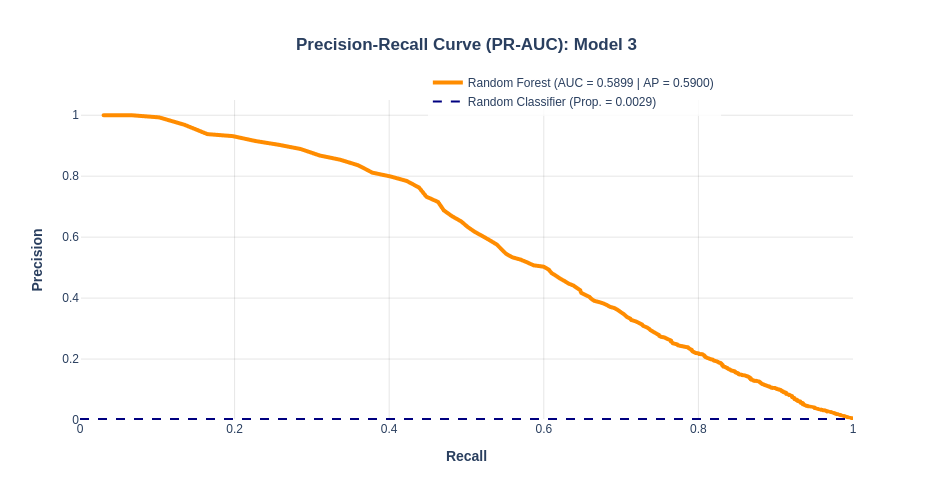

In [59]:
precision, recall, thresholds = precision_recall_curve(y_test, test_probs_3)
pr_auc_score = auc(recall, precision)
ap_score = average_precision_score(y_test, test_probs_3)

PRAUC_df = pl.DataFrame({"Recall": recall, "Precision": precision})

light_PRAUC_df = PRAUC_df.gather_every(50)
baseline = float(y_test.sum() / len(y_test))

fig = px.line(
    light_PRAUC_df, 
    x='Recall', 
    y='Precision',
    title='<b>Precision-Recall Curve (PR-AUC): Model 3</b>',
    labels={'Recall': '<b>Recall<b>', 'Precision': '<b>Precision<b>'}
)

fig.update_traces(
    line=dict(color='darkorange', width=4),
    name=f'Random Forest (AUC = {pr_auc_score:.4f} | AP = {ap_score:.4f})',
    showlegend=True,
    hovertemplate='<b>Recall:</b> %{x:.4f}<br><b>Precision:</b> %{y:.4f}<extra></extra>'
)

fig.add_shape(
    type="line", x0=0, y0=baseline, x1=1, y1=baseline,
    line=dict(color="navy", width=2, dash="dash"),
)

fig.add_trace(px.scatter(x=[None], y=[None], labels={'x':'', 'y':''}).data[0])

fig.data[-1].update(
    name=f'Random Classifier (Prop. = {baseline:.4f})', 
    showlegend=True, mode='lines',
    line=dict(color="navy", width=2, dash="dash")
)

fig.update_layout(
    width=700, height=500, title_x=0.5, autosize=False,
    xaxis=dict(range=[0.0, 1.0], gridcolor='rgba(0,0,0,0.1)'),
    yaxis=dict(range=[0.0, 1.05], gridcolor='rgba(0,0,0,0.1)'),
    plot_bgcolor='white',
    legend=dict(x=0.45, y=1.1, bgcolor='rgba(255, 255, 255, 0.8)')
)

fig.show()

In [61]:
# joblib.dump(best_rf_3, f"{path}mldl/ML_RandomForest_3.pkl")